# Feautre Extraction

Using MediaPipe pictures are converted to csv file for models.

In [1]:
import os
import cv2
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Settings
DATASET_DIR = "photos"              
MODEL_PATH = "hand_landmarker.task"
OUTPUT_CSV = "features.csv"
NUM_HANDS = 1

# MediaPipe Hand Landmarker
base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=NUM_HANDS)
detector = vision.HandLandmarker.create_from_options(options)

rows = []
not_found = 0
processed = 0

# column names: x0,y0,...,x20,y20 + label
columns = [f"{axis}{i}" for i in range(21) for axis in ["x", "y"]] + ["label"]

for gesture in sorted(os.listdir(DATASET_DIR)):
    gesture_path = os.path.join(DATASET_DIR, gesture)
    if not os.path.isdir(gesture_path):
        continue

    for img_file in os.listdir(gesture_path):
        img_path = os.path.join(gesture_path, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        processed += 1
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        result = detector.detect(mp_image)

        if not result.hand_landmarks:
            not_found += 1
            continue

        # take the first hand
        landmarks = result.hand_landmarks[0]

        # normalize according the wrist
        wrist_x = landmarks[0].x
        wrist_y = landmarks[0].y

        row = []
        for lm in landmarks:
            row.append(lm.x - wrist_x)
            row.append(lm.y - wrist_y)

        row.append(gesture)  # label
        rows.append(row)

df = pd.DataFrame(rows, columns=columns)
df.to_csv(OUTPUT_CSV, index=False)

print(f"Processed picture: {processed}")
print(f"Number of pictures that hand cannot be found: {not_found}")
print(f"Number of lines in CSV: {len(df)} -> {OUTPUT_CSV}")
print("\nClassification:")
print(df["label"].value_counts())

I0000 00:00:1776597005.661815 4810200 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776597005.675108 4810205 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776597005.685731 4810210 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776597005.741252 4810201 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Processed picture: 2192
Number of pictures that hand cannot be found: 0
Number of lines in CSV: 2192 -> features.csv

Classification:
label
fingergun      275
rocknroll      249
stop           249
mammamia       247
ok             245
approve        238
koreanheart    236
dissapprove    231
peace          222
Name: count, dtype: int64


In [4]:
df = pd.read_csv("features.csv")
display(df.head())

,x0,y0,x1,y1,x2,y2,x3,y3,x4,y4,...,y16,x17,y17,x18,y18,x19,y19,x20,y20,label
0,0.0,0.0,0.022966,-0.225134,0.081754,-0.354519,0.162364,-0.434407,0.202123,-0.522816,...,-0.046701,0.207724,0.087216,0.209920,0.034193,0.179677,0.021735,0.149482,0.023387,approve
1,0.0,0.0,0.012389,-0.176183,0.059183,-0.278440,0.121827,-0.337962,0.149358,-0.405101,...,-0.029925,0.152830,0.062044,0.147158,0.039101,0.124820,0.030712,0.102933,0.026577,approve
2,0.0,0.0,0.037160,-0.074611,0.082818,-0.117542,0.121514,-0.151840,0.142124,-0.192799,...,0.018586,0.093895,0.044583,0.122924,0.057868,0.101386,0.055043,0.083579,0.045062,approve
3,0.0,0.0,-0.018256,-0.092348,-0.011938,-0.165985,-0.004628,-0.232131,-0.011828,-0.280704,...,-0.077509,0.111178,-0.044571,0.137111,-0.069020,0.117115,-0.051553,0.098232,-0.040157,approve
4,0.0,0.0,0.017364,-0.054452,0.039597,-0.093590,0.060203,-0.126252,0.068985,-0.156210,...,0.000292,0.074319,0.038414,0.079116,0.031271,0.067721,0.027238,0.055963,0.024984,approve


### Class Distrubition

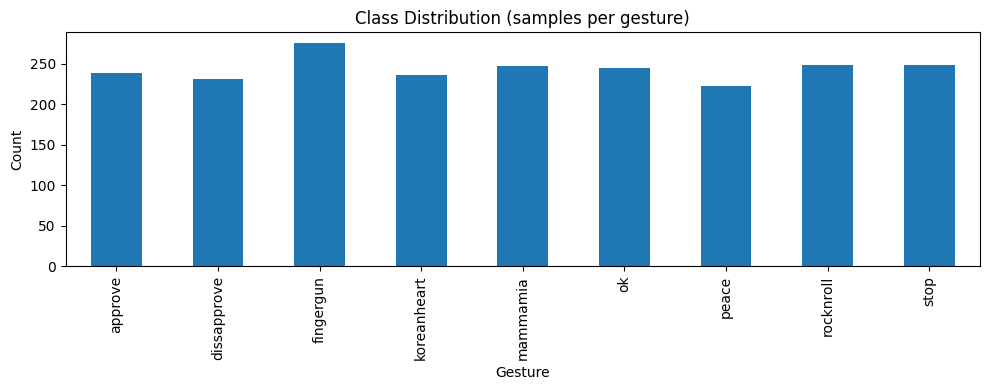

In [5]:
import matplotlib.pyplot as plt

counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.title("Class Distribution (samples per gesture)")
plt.xlabel("Gesture")
plt.ylabel("Count")
plt.tight_layout()
plt.show()